In [28]:
import pandas as pd
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
load_dotenv()

True

In [3]:
# carregando dataset de transferências
path = os.getenv('DATASETS_PATH')
df = pd.read_csv(path + '/transfers.csv')
df.head()

,player_id,transfer_date,transfer_season,from_club_id,to_club_id,from_club_name,to_club_name,transfer_fee,market_value_in_eur,player_name
0,467994,2030-06-30,25/26,5621,749,Reggiana,FC Empoli,0.0,700000.0,Luca Belardinelli
1,645842,2028-02-02,27/28,6505,19684,Gimcheon Sangmu,Jeju SK,0.0,150000.0,Chan-gi An
2,677470,2028-02-02,27/28,6505,3535,Gimcheon Sangmu,Ulsan HD,0.0,400000.0,Yool Heo
3,709155,2028-02-02,27/28,6505,19684,Gimcheon Sangmu,Jeju SK,0.0,325000.0,Jae-hyeok Oh
4,728133,2028-02-02,27/28,6505,35759,Gimcheon Sangmu,Bucheon FC,0.0,175000.0,Sang-hyeok Lee


In [4]:
# vendo informações do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175043 entries, 0 to 175042
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   player_id            175043 non-null  int64  
 1   transfer_date        175043 non-null  object 
 2   transfer_season      175043 non-null  object 
 3   from_club_id         175043 non-null  int64  
 4   to_club_id           175043 non-null  int64  
 5   from_club_name       175043 non-null  object 
 6   to_club_name         175043 non-null  object 
 7   transfer_fee         113584 non-null  float64
 8   market_value_in_eur  106982 non-null  float64
 9   player_name          175043 non-null  object 
dtypes: float64(2), int64(3), object(5)
memory usage: 13.4+ MB


In [5]:
# contando quantas vezes o valor de compra foi 0
df[df['transfer_fee'] == 0]['transfer_fee'].count()

96033

In [6]:
# contando quantas vezes o valor de compra foi maior que zero
df[df['transfer_fee'] > 0]['transfer_fee'].count()

17551

In [24]:
# quantas vezes o valor de transferência não está preenchido
df['transfer_fee'].isna().sum()

61459

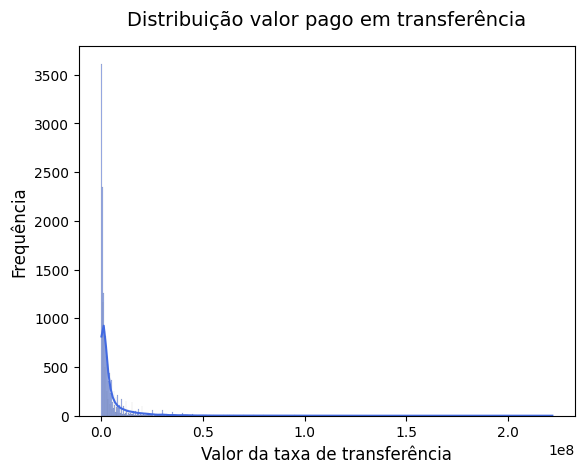

In [30]:
# dataframe com valores acima de 0 em valor de mercado
df_temp = df[df['transfer_fee'] > 0].dropna(subset=['transfer_fee'])

# histograma simples com a distribuição de valor de mercado
sns.histplot(data=df_temp, x='transfer_fee', kde=True, color='royalblue');

# Customização de títulos e eixos
plt.title('Distribuição valor pago em transferência', fontsize=14, pad=15)
plt.xlabel('Valor da taxa de transferência', fontsize=12)
plt.ylabel('Frequência', fontsize=12)

# Exibe o gráfico e salva
plot_path = os.getenv('PLOTS_PATH')
plt.savefig(plot_path + '/distribution_transfer_fee.png', dpi=300, bbox_inches='tight')
plt.show()

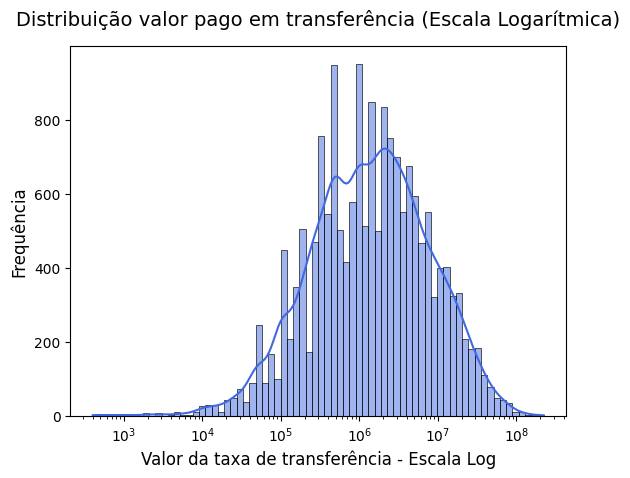

In [31]:
# dataframe com valores acima de 0 em valor de mercado
df_temp = df[df['transfer_fee'] > 0].dropna(subset=['transfer_fee'])

# histografico com a distribuição de valor de mercado
sns.histplot(data=df_temp, x='transfer_fee', log_scale=True, kde=True, color='royalblue');

# Customização de títulos e eixos
plt.title('Distribuição valor pago em transferência (Escala Logarítmica)', fontsize=14, pad=15)
plt.xlabel('Valor da taxa de transferência - Escala Log', fontsize=12)
plt.ylabel('Frequência', fontsize=12)

# Exibe o gráfico e salva
plot_path = os.getenv('PLOTS_PATH')
plt.savefig(plot_path + '/distribution_transfer_fee_log.png', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
# modificando para o formato de data correto e criando a tabela year
df_temp = df
df_temp['year'] = pd.to_datetime(df_temp['transfer_date']).dt.year
df_temp.head()

,player_id,transfer_date,transfer_season,from_club_id,to_club_id,from_club_name,to_club_name,transfer_fee,market_value_in_eur,player_name,year
0,467994,2030-06-30,25/26,5621,749,Reggiana,FC Empoli,0.0,700000.0,Luca Belardinelli,2030
1,645842,2028-02-02,27/28,6505,19684,Gimcheon Sangmu,Jeju SK,0.0,150000.0,Chan-gi An,2028
2,677470,2028-02-02,27/28,6505,3535,Gimcheon Sangmu,Ulsan HD,0.0,400000.0,Yool Heo,2028
3,709155,2028-02-02,27/28,6505,19684,Gimcheon Sangmu,Jeju SK,0.0,325000.0,Jae-hyeok Oh,2028
4,728133,2028-02-02,27/28,6505,35759,Gimcheon Sangmu,Bucheon FC,0.0,175000.0,Sang-hyeok Lee,2028


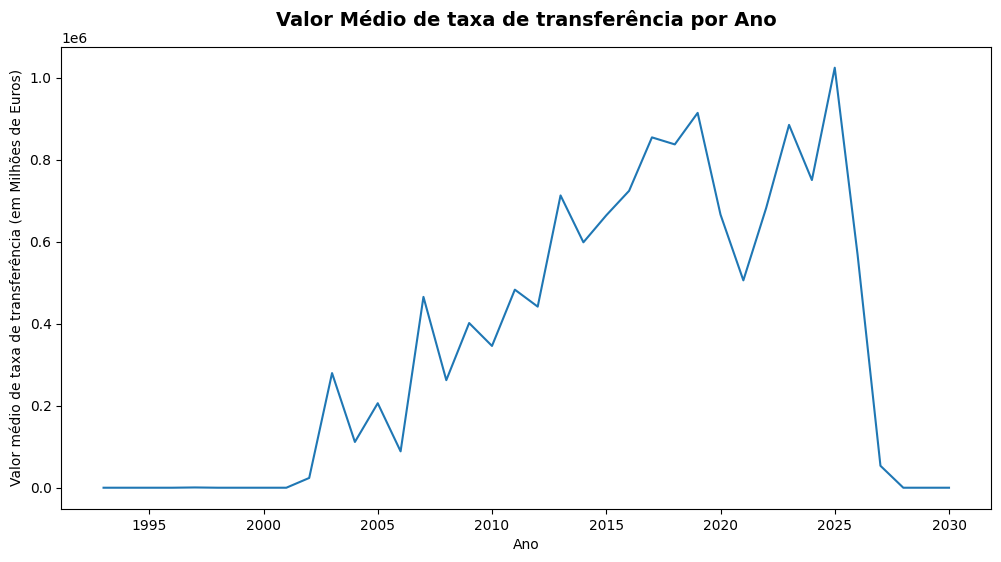

In [36]:
# Calculando o valor médio por ano
mvby = df_temp.groupby('year')['transfer_fee'].mean()

# Configurações visuais do gráfico
plt.figure(figsize=(12, 6))
plt.plot(mvby)
plt.title('Valor Médio de taxa de transferência por Ano', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ano')
plt.ylabel('Valor médio de taxa de transferência (em Milhões de Euros)')

# exibe o grafico e salva
plot_path = os.getenv('PLOTS_PATH')
plt.savefig(plot_path + '/mean_transfer_fee_by_year.png', dpi=300, bbox_inches='tight') 
plt.show()


In [41]:
# vendo quem mais gasta para comprar
top_buyers = df_temp.groupby('to_club_name')['transfer_fee'].sum().sort_values(ascending=False)
top_buyers.head()

to_club_name
Chelsea      3.005150e+09
Man City     2.478430e+09
Man Utd      2.379150e+09
PSG          2.010620e+09
Liverpool    1.853955e+09
Name: transfer_fee, dtype: float64

In [42]:
# vendo quem mais ganha vendendo
top_sellers = df_temp.groupby('from_club_name')['transfer_fee'].sum().sort_values(ascending=False)
top_sellers.head()

from_club_name
Benfica     1.546940e+09
Chelsea     1.384480e+09
Monaco      1.276670e+09
Ajax        1.162340e+09
Juventus    1.111870e+09
Name: transfer_fee, dtype: float64